In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

2026-06-07 14:27:21.590409: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780842441.974035      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780842442.087327      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780842443.059615      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780842443.059657      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780842443.059660      16 computation_placer.cc:177] computation placer alr

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [3]:
import os

BASE = "/kaggle/input"

for root, dirs, files in os.walk(BASE):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/shrutisaxena
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/virabhadrasana i
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/janu sirsasana
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/chaturanga dandasana
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/ashtanga namaskara
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/camatkarasana
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/gomukhasana
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset/makarasana
/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/data

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Sequential
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [5]:
dataset_path = "/kaggle/input/datasets/shrutisaxena/yoga-pose-image-classification-dataset/dataset"

print("Number of classes:", len(os.listdir(dataset_path)))
print(os.listdir(dataset_path)[:10])

Number of classes: 107
['virabhadrasana i', 'janu sirsasana', 'chaturanga dandasana', 'ashtanga namaskara', 'camatkarasana', 'gomukhasana', 'makarasana', 'padmasana', 'savasana', 'vajrasana']


In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Classes:", len(class_names))

Found 5993 files belonging to 107 classes.
Using 4795 files for training.


2026-06-07 14:27:57.113901: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 5993 files belonging to 107 classes.
Using 1198 files for validation.
Classes: 107


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

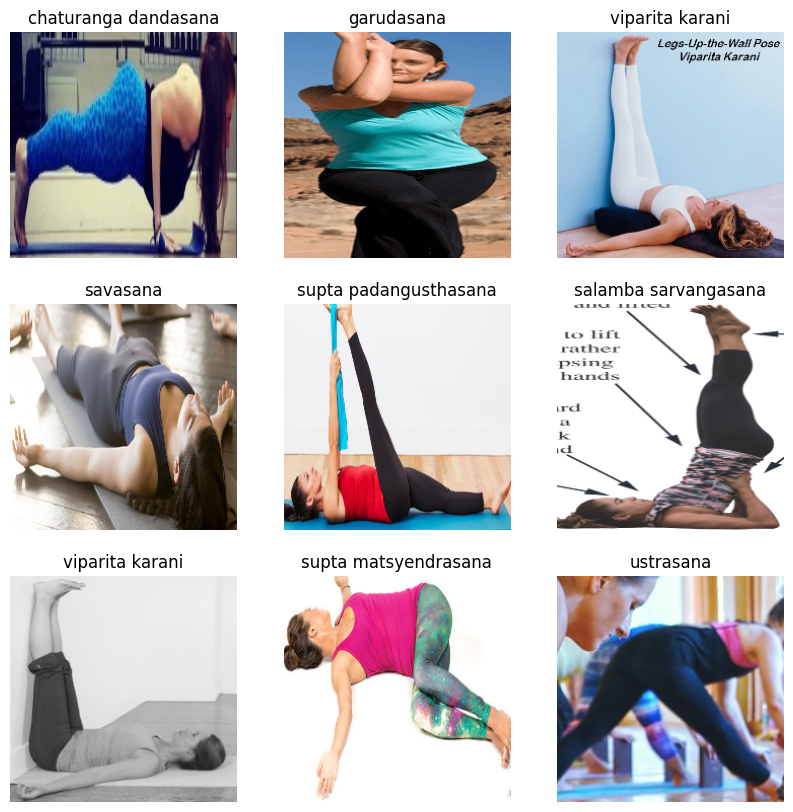

In [8]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [9]:
data_aug = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])

In [10]:
model = Sequential([
    layers.Rescaling(1./255, input_shape=(224,224,3)),

    data_aug,

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 107)            │        13,803 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,182,763 (42.66 MB)

 Trainable params: 11,182,763 (42.66 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - accuracy: 0.0146 - loss: 4.7127 - val_accuracy: 0.0058 - val_loss: 4.6718
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 300s 2s/step - accuracy: 0.0181 - loss: 4.6582 - val_accuracy: 0.0175 - val_loss: 4.6428
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 298s 2s/step - accuracy: 0.0284 - loss: 4.6086 - val_accuracy: 0.0376 - val_loss: 4.5331
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.0342 - loss: 4.5090 - val_accuracy: 0.0434 - val_loss: 4.3930
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.0465 - loss: 4.3948 - val_accuracy: 0.0668 - val_loss: 4.2600
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.0540 - loss: 4.3060 - val_accuracy: 0.0718 - val_loss: 4.1356
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 299s 2s/step - accuracy: 0.0626 - loss: 4.2304 - val_accuracy: 0.1018 - val_loss: 4.0450
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 298s 2s/step - accuracy: 0.0726 - loss: 4.1711 - val_accu

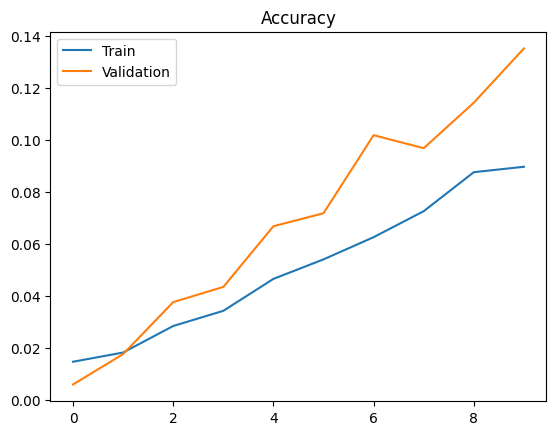

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

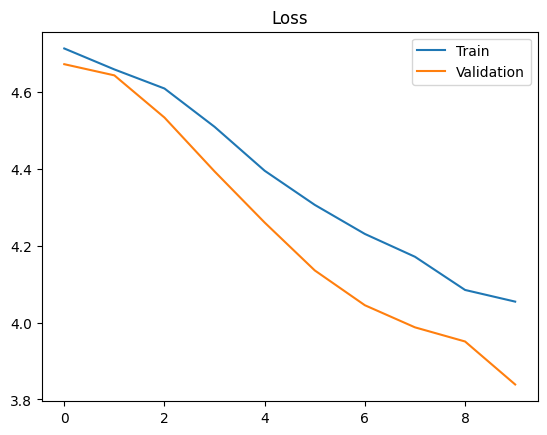

In [13]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Validation"])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 593ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

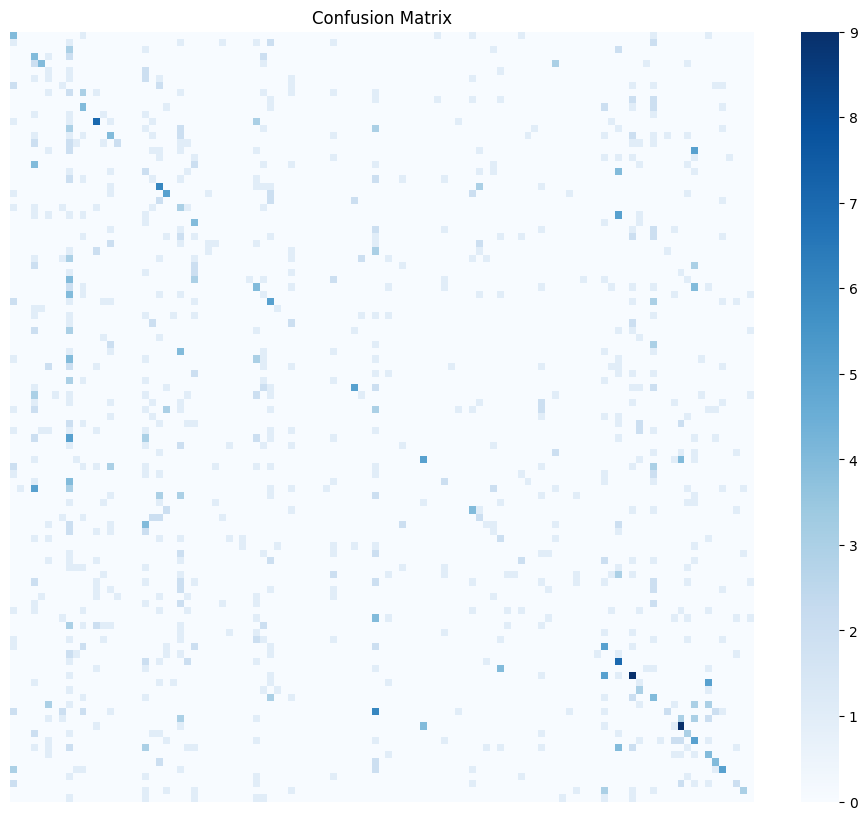

In [14]:
y_true, y_pred = [], []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix")
plt.show()

In [15]:
print(classification_report(y_true, y_pred, target_names=class_names))

                               precision    recall  f1-score   support

         adho mukha svanasana       0.14      0.40      0.21        10
        adho mukha vriksasana       0.00      0.00      0.00        10
              agnistambhasana       0.00      0.00      0.00         7
              ananda balasana       0.08      0.44      0.14         9
                   anantasana       0.57      0.33      0.42        12
                 anjaneyasana       0.05      0.20      0.08         5
              ardha bhekasana       0.00      0.00      0.00         8
            ardha chandrasana       0.12      0.10      0.11        10
         ardha matsyendrasana       0.02      0.17      0.04        12
      ardha pincha mayurasana       0.00      0.00      0.00         9
             ardha uttanasana       0.15      0.33      0.21        12
           ashtanga namaskara       0.00      0.00      0.00         5
                astavakrasana       0.30      0.44      0.36        16
     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights=None
)

base_model.trainable = False

x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
output = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)

tl_model = tf.keras.Model(base_model.input, output)

tl_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
tl_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,435,755 (9.29 MB)

 Trainable params: 177,771 (694.42 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
history_tl = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 131s 837ms/step - accuracy: 0.0129 - loss: 4.6701 - val_accuracy: 0.0100 - val_loss: 4.6702
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 140s 827ms/step - accuracy: 0.0150 - loss: 4.6592 - val_accuracy: 0.0100 - val_loss: 4.6689
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 124s 824ms/step - accuracy: 0.0173 - loss: 4.6469 - val_accuracy: 0.0100 - val_loss: 4.6735
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 142s 827ms/step - accuracy: 0.0150 - loss: 4.6430 - val_accuracy: 0.0083 - val_loss: 4.6770
Epoch 5/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 142s 827ms/step - accuracy: 0.0154 - loss: 4.6408 - val_accuracy: 0.0083 - val_loss: 4.6791


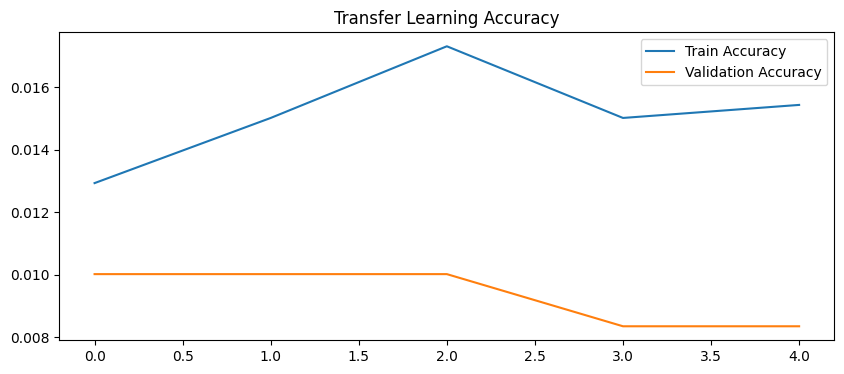

In [19]:
plt.figure(figsize=(10,4))

plt.plot(history_tl.history['accuracy'], label='Train Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')

plt.title("Transfer Learning Accuracy")
plt.legend()
plt.show()

In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = tl_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 711ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 683ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 742ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 670ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 696ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 709ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 716ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 693ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

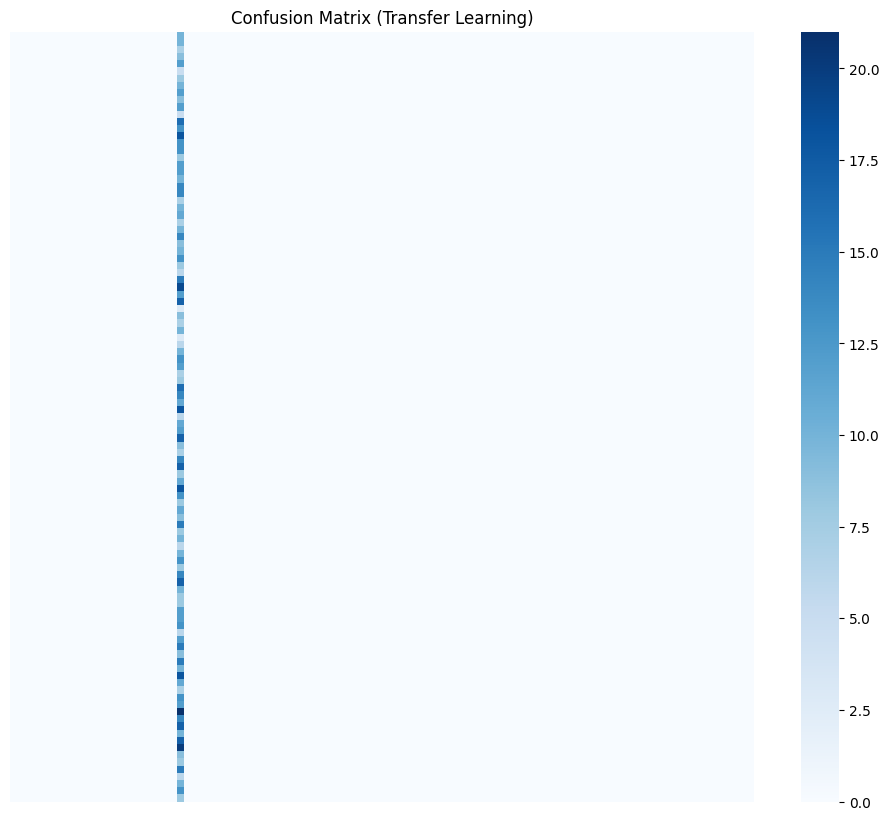

In [21]:
plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title("Confusion Matrix (Transfer Learning)")
plt.show()

In [22]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                               precision    recall  f1-score   support

         adho mukha svanasana       0.00      0.00      0.00        10
        adho mukha vriksasana       0.00      0.00      0.00        10
              agnistambhasana       0.00      0.00      0.00         7
              ananda balasana       0.00      0.00      0.00         9
                   anantasana       0.00      0.00      0.00        12
                 anjaneyasana       0.00      0.00      0.00         5
              ardha bhekasana       0.00      0.00      0.00         8
            ardha chandrasana       0.00      0.00      0.00        10
         ardha matsyendrasana       0.00      0.00      0.00        12
      ardha pincha mayurasana       0.00      0.00      0.00         9
             ardha uttanasana       0.00      0.00      0.00        12
           ashtanga namaskara       0.00      0.00      0.00         5
                astavakrasana       0.00      0.00      0.00        16
     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
tl_model.save("yoga_pose_transfer_model.h5")
model.save("yoga_pose_cnn_model.h5")